<a href="https://colab.research.google.com/github/kennethkvs/RetinalDiseasesOCTClassifier/blob/main/RetinalDiseaseOCTClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Retinal Disease OCT Classifier (COMPSCI 4AL3 Assignment)


In [1]:
# Imports
import os
import numpy as np
import pandas as pd
from PIL import Image
import sklearn
import matplotlib.pyplot as plt

# PyTorch Imports
import torch
from torchvision.transforms import v2 as image_preprocess
from torch.utils.data import DataLoader
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim

# Sklearn Imports
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
# Dataset Class Definition
class OCTImageDataset:
    def __init__(self, data_dir: str, type: str):
        self.data_dir = data_dir
        self.type = type
        self.label_mapping = {
            'CNV': 0,
            'DME': 1,
            'DRUSEN': 2,
            'NORMAL': 3
        }
        self.image_paths = []
        self.classes = list(self.label_mapping.keys())
        self.labels = []
        self.image_processor = None

        # Initialize class attributes
        match type:
            case 'train':
                self.image_processor = image_preprocess.Compose([
                    # Convert to tensor since input is a PIL image
                    image_preprocess.ToImage(), 
                    image_preprocess.ToDtype(torch.uint8, scale=True),
                    # Crop
                    image_preprocess.Resize((224, 224), antialias=True),
                    # Different transformations
                    image_preprocess.RandomHorizontalFlip(),
                    # Normalize
                    image_preprocess.ToDtype(torch.float32, scale=True),  # Normalize expects float input according to docs
                    image_preprocess.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
                ])
            case 'test' | 'val':
                self.image_processor = image_preprocess.Compose([
                    # Convert to tensor since input is a PIL image
                    image_preprocess.ToImage(), 
                    image_preprocess.ToDtype(torch.uint8, scale=True),
                    # Crop
                    image_preprocess.Resize((224, 224), antialias=True),
                    # Normalize
                    image_preprocess.ToDtype(torch.float32, scale=True),  # Normalize expects float input according to docs
                    image_preprocess.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
                ])
            case _:
                raise ValueError("Type must be 'train', 'val', or 'test'.")
        self.load_data()

    def load_data(self):
        for label in os.listdir(self.data_dir):
            label_dir = os.path.join(self.data_dir, label)
            if os.path.isdir(label_dir):
                for image_file in os.listdir(label_dir):
                    if image_file.endswith(('.png', '.jpg', '.jpeg')):
                        image_path = os.path.join(label_dir, image_file)
                        self.image_paths.append(image_path)
                        self.labels.append(self.label_mapping[label])
        
        print(f"Loaded {len(self.image_paths)} images for {self.type} set.")

    def visualize(self):
        # Print out dataset statistics
        class_counts = {
            'CNV': self.labels.count(0),
            'DME': self.labels.count(1),
            'DRUSEN': self.labels.count(2),
            'NORMAL': self.labels.count(3)
        }
        print(f"Visualizing dataset statistics for {self.type} set:")
        for class_name, count in class_counts.items():
            print(f"{class_name}: {count} images")
        
        # Plot class distribution
        plt.bar(class_counts.keys(), class_counts.values())
        plt.title(f'Class Distribution in {self.type} Set')
        plt.xlabel('Classes')
        plt.ylabel('Number of Images')
        plt.show()

        # Display sample images from each class
        plt.figure(figsize=(12, 6))
        for class_name in self.classes:
            # Pick the first image from each class for visualization
            image_path = os.path.join(self.data_dir, class_name, os.listdir(os.path.join(self.data_dir, class_name))[0])
            image = Image.open(image_path)
            plt.subplot(1, 4, self.label_mapping[class_name] + 1)
            plt.imshow(image, cmap='gray') # Image data is grayscale idk why without cmap it isn't grayscale
            plt.title(class_name)
        plt.show()

    # Needed for PyTorch DataLoader compatibility
    def __len__(self):
        if len(self.image_paths) != len(self.labels):
            raise ValueError("Mismatch between number of images and labels.")
        if len(self.image_paths) == 0 or len(self.labels) == 0:
            raise ValueError("No images found in the dataset.")

        return len(self.image_paths)
    
    # Needed for PyTorch DataLoader compatibility
    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        label = self.labels[idx]

        image = Image.open(image_path).convert('RGB')
        if self.image_processor:
            image = self.image_processor(image)
        else:
            raise ValueError("Image processor not defined.")
        
        return image, label


In [3]:
# Data Configurations
batch_size = 64
shuffle_data = True
# train_data_dir = 'Dataset/train'
# test_data_dir = 'Dataset/test'
# val_data_dir = 'Dataset/val'

train_data_dir = '1000_images_only/train'
test_data_dir = '1000_images_only/test'
val_data_dir = '1000_images_only/val'

Loaded 4000 images for train set.
Visualizing dataset statistics for train set:
CNV: 1000 images
DME: 1000 images
DRUSEN: 1000 images
NORMAL: 1000 images


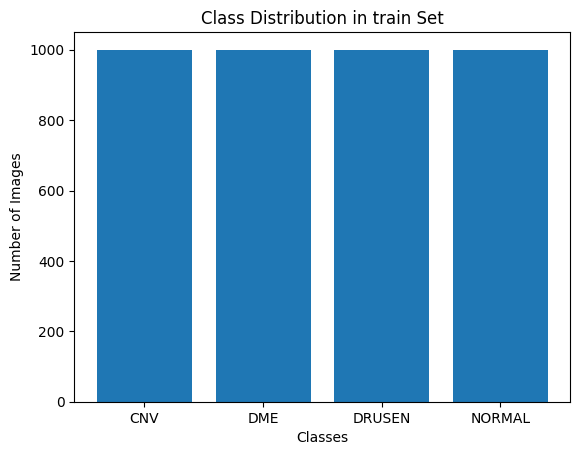

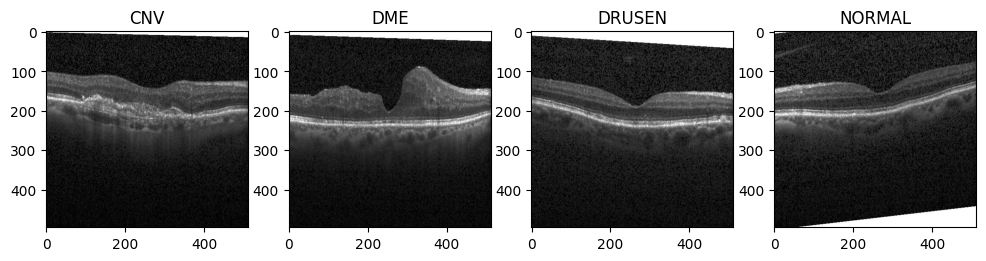

Sample training data tensor
(Image([[[ 2.2489,  2.2489,  2.2489,  ...,  2.2147,  2.1975,  2.1975],
        [ 2.2489,  2.2489,  2.2489,  ..., -0.1143, -0.3027, -0.2513],
        [ 2.2489,  2.2489,  2.2489,  ..., -1.5699, -1.6898, -1.6898],
        ...,
        [-2.0323, -2.0152, -2.0665,  ..., -2.0323, -2.0152, -2.0494],
        [-2.0152, -2.0152, -1.9809,  ..., -2.0665, -2.0152, -2.0152],
        [-2.0323, -2.0837, -2.0152,  ..., -2.0323, -2.0152, -2.0665]],

       [[ 2.4286,  2.4286,  2.4286,  ...,  2.3936,  2.3761,  2.3761],
        [ 2.4286,  2.4286,  2.4286,  ...,  0.0126, -0.1800, -0.1275],
        [ 2.4286,  2.4286,  2.4286,  ..., -1.4755, -1.5980, -1.5980],
        ...,
        [-1.9482, -1.9307, -1.9832,  ..., -1.9482, -1.9307, -1.9657],
        [-1.9307, -1.9307, -1.8957,  ..., -1.9832, -1.9307, -1.9307],
        [-1.9482, -2.0007, -1.9307,  ..., -1.9482, -1.9307, -1.9832]],

       [[ 2.6400,  2.6400,  2.6400,  ...,  2.6051,  2.5877,  2.5877],
        [ 2.6400,  2.6400,  2.6

In [4]:
# Training Dataset Initialization
training_data = OCTImageDataset(data_dir=train_data_dir, type='train')
training_data.visualize()
print(f'Sample training data tensor\n{training_data[0]}')

# Training Data Loader
training_data_loader = DataLoader(dataset=training_data, batch_size=batch_size, shuffle=shuffle_data)

Loaded 968 images for test set.
Visualizing dataset statistics for test set:
CNV: 242 images
DME: 242 images
DRUSEN: 242 images
NORMAL: 242 images


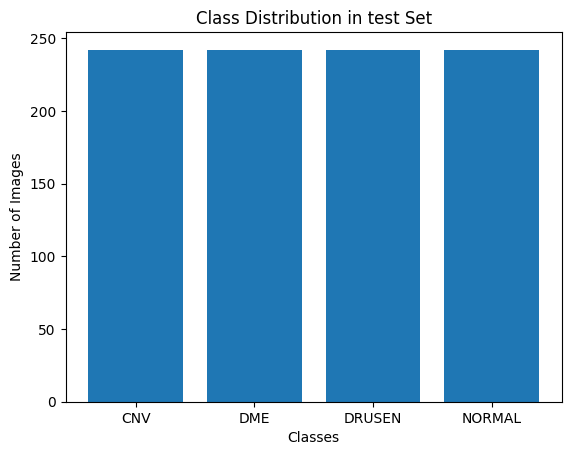

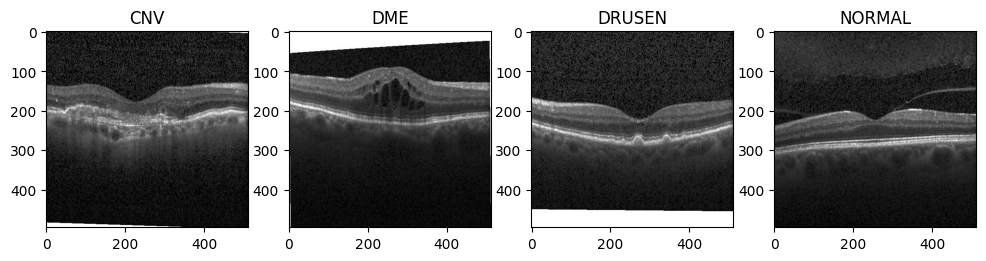

Sample testing data tensor
(Image([[[-1.8610, -1.5528, -1.7754,  ...,  2.1975,  2.2147,  2.2147],
        [-1.7069, -1.7754, -1.9467,  ...,  2.1975,  2.1975,  2.1804],
        [-1.6727, -1.7069, -1.8268,  ..., -0.5596, -0.5082, -0.8335],
        ...,
        [ 2.2489,  2.2489,  2.2489,  ..., -1.9980, -2.0837, -2.0837],
        [ 2.2489,  2.2489,  2.2489,  ..., -2.0323, -2.0837, -2.0665],
        [ 2.2489,  2.2489,  2.2489,  ..., -2.0494, -2.1008, -2.1179]],

       [[-1.7731, -1.4580, -1.6856,  ...,  2.3761,  2.3936,  2.3936],
        [-1.6155, -1.6856, -1.8606,  ...,  2.3761,  2.3761,  2.3585],
        [-1.5805, -1.6155, -1.7381,  ..., -0.4426, -0.3901, -0.7227],
        ...,
        [ 2.4286,  2.4286,  2.4286,  ..., -1.9132, -2.0007, -2.0007],
        [ 2.4286,  2.4286,  2.4286,  ..., -1.9482, -2.0007, -1.9832],
        [ 2.4286,  2.4286,  2.4286,  ..., -1.9657, -2.0182, -2.0357]],

       [[-1.5430, -1.2293, -1.4559,  ...,  2.5877,  2.6051,  2.6051],
        [-1.3861, -1.4559, -1.63

In [5]:
# Testing Dataset Initialization
testing_data = OCTImageDataset(data_dir=test_data_dir, type='test')
testing_data.visualize()
print(f'Sample testing data tensor\n{testing_data[0]}')

# Testing Data Loader
testing_data_loader = DataLoader(dataset=testing_data, batch_size=batch_size, shuffle=shuffle_data)

Loaded 32 images for val set.
Visualizing dataset statistics for val set:
CNV: 8 images
DME: 8 images
DRUSEN: 8 images
NORMAL: 8 images


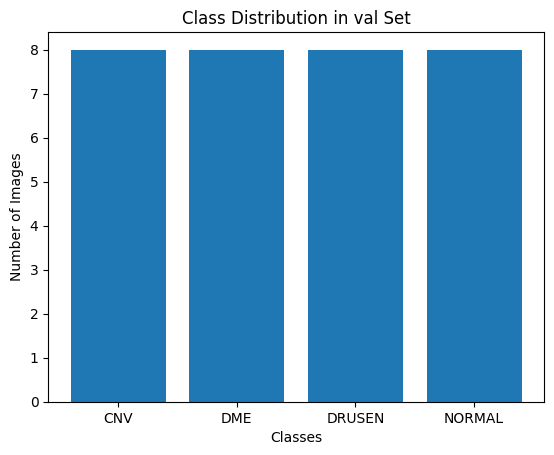

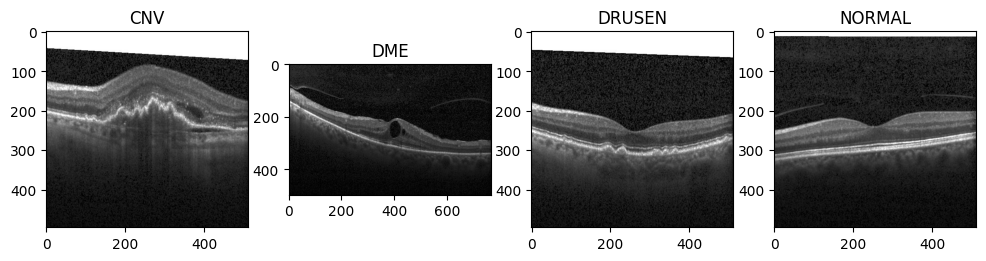

Sample validation data tensor
(Image([[[ 2.2489,  2.2489,  2.2489,  ...,  2.2489,  2.2489,  2.2489],
        [ 2.2489,  2.2489,  2.2489,  ...,  2.2489,  2.2489,  2.2489],
        [ 2.2489,  2.2489,  2.2489,  ...,  2.2489,  2.2489,  2.2489],
        ...,
        [-1.8097, -1.8610, -1.8268,  ..., -2.0494, -1.9467, -1.9809],
        [-1.7583, -1.8268, -1.7925,  ..., -1.9980, -1.9467, -1.9638],
        [-1.8268, -1.8953, -1.8439,  ..., -1.8782, -1.9980, -2.0494]],

       [[ 2.4286,  2.4286,  2.4286,  ...,  2.4286,  2.4286,  2.4286],
        [ 2.4286,  2.4286,  2.4286,  ...,  2.4286,  2.4286,  2.4286],
        [ 2.4286,  2.4286,  2.4286,  ...,  2.4286,  2.4286,  2.4286],
        ...,
        [-1.7206, -1.7731, -1.7381,  ..., -1.9657, -1.8606, -1.8957],
        [-1.6681, -1.7381, -1.7031,  ..., -1.9132, -1.8606, -1.8782],
        [-1.7381, -1.8081, -1.7556,  ..., -1.7906, -1.9132, -1.9657]],

       [[ 2.6400,  2.6400,  2.6400,  ...,  2.6400,  2.6400,  2.6400],
        [ 2.6400,  2.6400,  2

In [6]:
# Validation Dataset Initialization
val_data = OCTImageDataset(data_dir=val_data_dir, type='val')
val_data.visualize()
print(f'Sample validation data tensor\n{val_data[0]}')

# Training Data Loader
val_data_loader = DataLoader(dataset=val_data, batch_size=batch_size, shuffle=shuffle_data)

### Machine Learning Model: ResNet Transfer Learning

Following the guide: https://www.geeksforgeeks.org/deep-learning/how-to-implement-transfer-learning-in-pytorch/

- Using a ResNet-50 implementation with a pre-trained ResNet-50 model.

In [7]:
# Selecting the graphics card is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [8]:
# Defining the Model Architecture with Transfer Learning
class CustomResNet(nn.Module):
    def __init__(self,):
        super(CustomResNet, self).__init__()
        self.resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.features = nn.Sequential(*list(self.resnet.children())[:-1])  # All layers except the final FC layer
        self.classifier = nn.Linear(self.resnet.fc.in_features, 4)  # New final layer for 4 classes

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

# Instantiate the CustomResNet model, passing the pretrained model
model = CustomResNet().to(device)

# Freeze all layers except the final layer
for param in model.parameters():
    param.requires_grad = False

# Unfreeze last layer of the ResNet
for param in model.resnet.layer4.parameters():
    param.requires_grad = True

# Unfreeze the classifier layer allowing for fine-tuning
for param in model.classifier.parameters():
    param.requires_grad = True

# Compiling the Model
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)  # Only optimize the final layer parameters

print(f'Model ready for training:\n{model}')

Model ready for training:
CustomResNet(
  (resnet): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downs

Epoch [1/10], Training Loss: 0.4905
Epoch [2/10], Training Loss: 0.4955
Epoch [3/10], Training Loss: 0.4663
Epoch [4/10], Training Loss: 0.4637
Epoch [5/10], Training Loss: 0.4584
Epoch [6/10], Training Loss: 0.4673
Epoch [7/10], Training Loss: 0.4671
Epoch [8/10], Training Loss: 0.4766
Epoch [9/10], Training Loss: 0.4704
Epoch [10/10], Training Loss: 0.4419

-------------------------------------------------------------------------------------
Finished fine-tuning with 0.8216 training accuracy.
-------------------------------------------------------------------------------------

Confusion Matrix after Training:


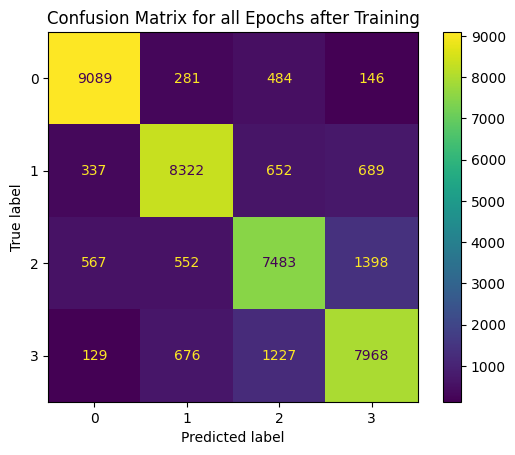


Model saved to Trained_Model/trained_resnet50_1000_images.pth


In [ ]:
## Training the Model ##
# Only trains if model doesn't already exist

from matplotlib import cm


if os.path.exists('Trained_Model/trained_resnet50_1000_images.pth'):
    # Extracting the model and naming it model so it can be fine tuned and evaluated
    model_path = 'Trained_Model/trained_resnet50_1000_images.pth'
    model.load_state_dict(torch.load(model_path, map_location=device))

    # Moving model to the appropriate device
    model.to(device)

    print("Trained model already exists. Skipping training.")
else:
    # Initialization parameters
    num_epochs = 10
    train_losses = []

    # Training accuracy counters
    train_correct = 0
    train_total = 0

    # Confusion matrix counters
    predicted_list = []
    labels_list = []

    # Training Loop
    for epoch in range(num_epochs):
        # Set model to training mode
        # Dropout is turned on and batchnorm updates its running statistics
        model.train()
        
        # Reset running loss, correct training amount, and total train ammount for each epoch
        running_loss = 0.0

        # Iterate over training data
        for images, labels in training_data_loader:
            # Move data to the appropriate device
            images, labels = images.to(device), labels.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Running forward pass
            outputs = model(images)

            # Compute loss and backpropagate
            loss = criterion(outputs, labels)
            loss.backward()

            # Update model parameters
            optimizer.step()

            # Update running loss and accuracy
            running_loss += loss.item()

            # Extracts predicted class index for each sample in the batch
            _, predicted = torch.max(outputs.data, 1)

            # Adds batch size to the running total number of samples processed
            train_total += labels.size(0)

            # Store predicted and true labels for confusion matrix
            # Moving it to the cpu in case it was on gpu memory
            predicted_list.extend(predicted.cpu().numpy())
            labels_list.extend(labels.cpu().numpy())

            # Adds number of correct predictions to running total
            train_correct += (predicted == labels).sum().item()

        # Compute average loss and accuracy for the epoch
        train_losses.append(running_loss / len(training_data_loader))
        print(f'Epoch [{epoch+1}/{num_epochs}], Training Loss: {running_loss / len(training_data_loader):.4f}')

    train_accuracy = train_correct / train_total
    print(f'\n-------------------------------------------------------------------------------------')
    print(f'Finished fine-tuning with {train_accuracy:.4f} training accuracy.')
    print(f'-------------------------------------------------------------------------------------')

    print(f'\nConfusion Matrix after Training:')
    cm = confusion_matrix(labels_list, predicted_list)
    matrix_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1, 2, 3])
    matrix_display.plot()
    plt.title(f"Confusion Matrix for all Epochs after Training")
    plt.show()

    # Saving the model
    model_save_path = 'Trained_Model/trained_resnet50_1000_images.pth'
    torch.save(model.state_dict(), model_save_path)
    print(f'\nModel saved to {model_save_path}')

Epoch [1/10], Validation Loss: 0.2415
Epoch [2/10], Validation Loss: 0.2415
Epoch [3/10], Validation Loss: 0.2415
Epoch [4/10], Validation Loss: 0.2415
Epoch [5/10], Validation Loss: 0.2415
Epoch [6/10], Validation Loss: 0.2415
Epoch [7/10], Validation Loss: 0.2415
Epoch [8/10], Validation Loss: 0.2415
Epoch [9/10], Validation Loss: 0.2415
Epoch [10/10], Validation Loss: 0.2415

-------------------------------------------------------------------------------------
Finished validation with 0.9062 validation accuracy.
-------------------------------------------------------------------------------------

Confusion Matrix after Validation:


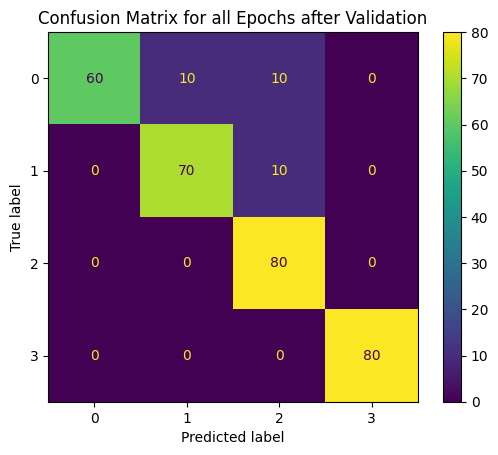

In [14]:
## Fine Evaluation on Validation Set ##

# Initialization parameters
num_epochs = 10
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Validation correct and total counters
val_correct = 0
val_total = 0

# Validation confusion matrix counters
val_predicted_list = []
val_labels_list = []

# Validation Loop
for epoch in range(num_epochs):
    # Set model to evaluation mode (Validation)
    # Dropout is turned off and batchnorm uses running statistics instead of updating them
    model.eval()

    # Reset running loss for each epoch
    val_loss = 0.0

    # Iterate over validation data while stopping gradient computation
    # This is important to prevent updating model parameters during validation
    # It also reduces memory consumption
    with torch.no_grad():
        for images, labels in val_data_loader:
            # Move data to the appropriate device
            images, labels = images.to(device), labels.to(device)

            # Running forward pass
            outputs = model(images)

            # Compute loss
            loss = criterion(outputs, labels)
            
            # Adds scalar loss value to running total, with .item converting the tensor to a Python float
            val_loss += loss.item()

            # Extracts predicted class index for each sample in the batch
            _, predicted = torch.max(outputs.data, 1)

            # Store predicted and true labels for confusion matrix
            # Moving it to the cpu in case it was on gpu memory
            val_predicted_list.extend(predicted.cpu().numpy())
            val_labels_list.extend(labels.cpu().numpy())

            # Adding batch size to the running total number of samples processed
            val_total += labels.size(0)

            # Compares predicted labels to true labels and sums correct predictions
            val_correct += (predicted == labels).sum().item()

    # Compute average lossfor the epoch
    val_loss_accuracy = val_loss / len(val_data_loader)
    val_losses.append(val_loss_accuracy)

    print(f'Epoch [{epoch+1}/{num_epochs}], Validation Loss: {val_loss_accuracy:.4f}')

# Compute average validation accuracy over all epochs
val_accuracy = val_correct / val_total
print(f'\n-------------------------------------------------------------------------------------')
print(f'Finished validation with {val_accuracy:.4f} validation accuracy.')
print(f'-------------------------------------------------------------------------------------')

print(f'\nConfusion Matrix after Validation:')
cm = confusion_matrix(val_labels_list, val_predicted_list)
matrix_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1, 2, 3])
matrix_display.plot()
plt.title(f"Confusion Matrix for all Epochs after Validation")
plt.show()

Epoch [1/10], Test Loss: 0.4011
Epoch [2/10], Test Loss: 0.3860
Epoch [3/10], Test Loss: 0.3952
Epoch [4/10], Test Loss: 0.3970
Epoch [5/10], Test Loss: 0.3898
Epoch [6/10], Test Loss: 0.3923
Epoch [7/10], Test Loss: 0.3916
Epoch [8/10], Test Loss: 0.4036
Epoch [9/10], Test Loss: 0.4416
Epoch [10/10], Test Loss: 0.3981

-------------------------------------------------------------------------------------
Final Test Accuracy: 0.8595 testing accuracy.
-------------------------------------------------------------------------------------

Confusion Matrix after Testing:


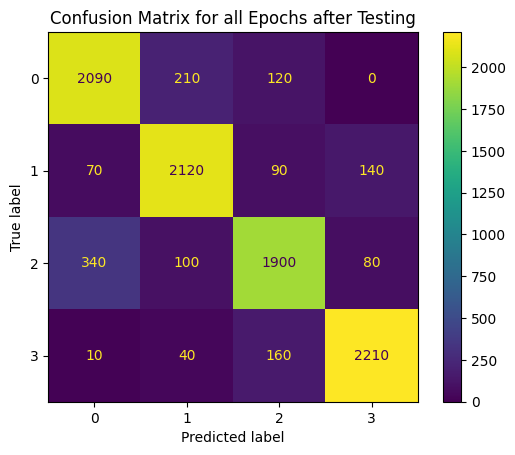

In [13]:
## Evaluating the Model ##

# Initialize variables for tracking performance
test_losses = []
epoch = 10

# Correct and total for accuracy calculation
correct = 0
total = 0

# Confusion matrix counters
test_predicted_list = []
test_labels_list = []

# Testing Loop
for epoch in range(num_epochs):
    # Set model to evaluation mode (Testing)
    model.eval()

    # Reset running loss for each epoch
    running_loss = 0.0

    # Iterate over testing data while stopping gradient computation
    # This is important to prevent updating model parameters during testing
    # It also reduces memory consumption
    with torch.no_grad():

        # Evaluate on test data
        for images, labels in testing_data_loader:
            # Move data to the appropriate device
            images, labels = images.to(device), labels.to(device)

            # Get model outputs
            outputs = model(images)

            # Compute loss (assuming your loss function is defined)
            loss = criterion(outputs, labels)

            # Update running loss
            running_loss += loss.item()

            # Calculate accuracy
            _, predicted = torch.max(outputs.data, 1) # Get the index of the maximum value

            # Store predicted and true labels for confusion matrix
            # Moving it to the cpu in case it was on gpu memory
            test_predicted_list.extend(predicted.cpu().numpy())
            test_labels_list.extend(labels.cpu().numpy())

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    # Calculate average loss for the epoch
    test_loss = running_loss / len(testing_data_loader)
    test_losses.append(test_loss)

    # Print epoch-wise performance
    print(f'Epoch [{epoch+1}/{num_epochs}], Test Loss: {test_loss:.4f}')

# Final Test Accuracy
test_accuracy = correct / total
print(f'\n-------------------------------------------------------------------------------------')
print(f'Final Test Accuracy: {test_accuracy:.4f} testing accuracy.')
print(f'-------------------------------------------------------------------------------------')

print(f'\nConfusion Matrix after Testing:')
cm = confusion_matrix(test_labels_list, test_predicted_list)
matrix_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1, 2, 3])
matrix_display.plot()
plt.title(f"Confusion Matrix for all Epochs after Testing")
plt.show()